In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import polars as pl

import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
augmented_df = pl.read_parquet("imputed_augmented_us-counties-states_latest_variants.parquet", low_memory=False).to_pandas()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

/home/zwang937/micromamba/envs/rapids-22.10/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
gt_columns = ["fips", "days_from_start", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


### Load TLGRF Benchmark Dataset

In [4]:
benchmark_TLGRF_dataset = pl.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", low_memory=False).to_pandas()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
0,1001,69,NaN,NaN,Autauga,Alabama,2020-03-30,5.142857,1.831438,2.469309,NaN
1,1001,70,NaN,NaN,Autauga,Alabama,2020-03-31,6.000000,1.960095,2.528012,NaN
2,1001,71,NaN,NaN,Autauga,Alabama,2020-04-01,6.857143,2.074070,2.550561,NaN
3,1001,72,NaN,NaN,Autauga,Alabama,2020-04-02,7.428571,2.143422,2.625703,NaN
4,1001,73,NaN,NaN,Autauga,Alabama,2020-04-03,8.285714,2.239189,2.676117,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3390311,99999,1153,1456.032249,-0.030986,New York City,New York,2023-03-19,13972.285714,9.544910,NaN,9.328005
3390312,99999,1154,1389.214236,-0.039535,New York City,New York,2023-03-20,13317.571429,9.496922,NaN,9.220178
3390313,99999,1155,1323.021840,-0.054503,New York City,New York,2023-03-21,12458.714286,9.430264,NaN,9.048744
3390314,99999,1156,1531.624962,-0.024711,New York City,New York,2023-03-22,12154.857143,9.405575,NaN,9.232600


### Read in LLF Results

In [5]:
def read_csv_file(file_path):
    # Read the CSV file into a pandas DataFrame
    try:
        GRF_df = pd.read_csv(file_path)
        return GRF_df
    except pd.errors.EmptyDataError:
        print(file_path)

In [7]:
directory = "./llf_results_cv/llf_backtest_state_forests_windowsize=2_numtrees=200"
llf_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(llf_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    llf_results_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in llf_results_file_paths)
    pbar.update(len(llf_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1107 [00:00<?, ?it/s]

In [8]:
llf_results = pd.concat(llf_results_dfs).sort_values(by=["fips", "days_from_start"])
llf_results["date"] = pd.to_datetime(llf_results["date"])
llf_results = llf_results.rename(columns={"predicted_log_rolled_cases_LLF":"LLF_predicted_log_rolled_cases"})
llf_results = llf_results.dropna(subset=["LLF_predicted_log_rolled_cases"])
llf_results = pd.merge(llf_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(llf_results)

,date,county,state,days_from_start,rolled_cases,fips,log_rolled_cases,r_LLF,var_r_LFF,LLF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,2020-04-17,Autauga,Alabama,87,20.714286,1001,3.030824,2.090668e-02,0.000000,3.177170,3.170286
1,2020-04-18,Autauga,Alabama,88,20.714286,1001,3.030824,-4.186207e-15,0.000000,3.030824,3.205646
2,2020-04-19,Autauga,Alabama,89,21.000000,1001,3.044522,1.369884e-02,0.000000,3.140414,3.228543
3,2020-04-20,Autauga,Alabama,90,21.428571,1001,3.064725,2.020271e-02,0.000000,3.206144,3.256447
4,2020-04-21,Autauga,Alabama,91,21.428571,1001,3.064725,-9.015990e-15,0.000000,3.064725,3.283593
...,...,...,...,...,...,...,...,...,...,...,...
2640623,2023-03-19,New York City,New York,1153,13972.285714,99999,9.544831,-3.446605e-02,0.000006,9.303569,NaN
2640624,2023-03-20,New York City,New York,1154,13317.571429,99999,9.496840,-3.857645e-02,0.000032,9.226804,NaN
2640625,2023-03-21,New York City,New York,1155,12458.714286,99999,9.430176,-6.666400e-02,0.000000,8.963528,NaN
2640626,2023-03-22,New York City,New York,1156,12154.857143,99999,9.405484,-2.469147e-02,0.000000,9.232644,NaN


In [9]:
directory = "./classical_llf_results/llf_backtest_state_forests_windowsize=2_numtrees=200"
classical_llf_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(classical_llf_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    classical_llf_results_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in classical_llf_results_file_paths)
    pbar.update(len(classical_llf_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1109 [00:00<?, ?it/s]

In [10]:
classical_llf_results = pd.concat(classical_llf_results_dfs).sort_values(by=["fips", "days_from_start"])
classical_llf_results["date"] = pd.to_datetime(classical_llf_results["date"])
classical_llf_results = classical_llf_results.rename(columns={"predicted_log_rolled_cases_LLF":"LLF_predicted_log_rolled_cases"})
classical_llf_results = classical_llf_results.dropna(subset=["LLF_predicted_log_rolled_cases"])
classical_llf_results = pd.merge(classical_llf_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(classical_llf_results)

,date,county,state,days_from_start,rolled_cases,fips,log_rolled_cases,r_LLF,var_r_LFF,LLF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,2020-04-17,Autauga,Alabama,87,20.714286,1001,3.030824,2.090668e-02,0.0,3.177170,3.170286
1,2020-04-18,Autauga,Alabama,88,20.714286,1001,3.030824,3.394876e-16,0.0,3.030824,3.205646
2,2020-04-19,Autauga,Alabama,89,21.000000,1001,3.044522,1.369884e-02,0.0,3.140414,3.228543
3,2020-04-20,Autauga,Alabama,90,21.428571,1001,3.064725,2.020271e-02,0.0,3.206144,3.256447
4,2020-04-21,Autauga,Alabama,91,21.428571,1001,3.064725,-4.437702e-16,0.0,3.064725,3.283593
...,...,...,...,...,...,...,...,...,...,...,...
2646423,2023-03-19,New York City,New York,1153,13972.285714,99999,9.544831,-3.331212e-02,0.0,9.311646,NaN
2646424,2023-03-20,New York City,New York,1154,13317.571429,99999,9.496840,-4.799145e-02,0.0,9.160899,NaN
2646425,2023-03-21,New York City,New York,1155,12458.714286,99999,9.430176,-6.666400e-02,0.0,8.963528,NaN
2646426,2023-03-22,New York City,New York,1156,12154.857143,99999,9.405484,-2.469147e-02,0.0,9.232644,NaN


### Metrics

In [11]:
rmse_LLF_func = lambda x: np.sqrt(np.nanmean((x["LLF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_LLF_func = lambda x: np.nanmean(np.abs(x["LLF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
#

log_20 = np.log(20 + 1.1)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= log_20]
TLGRF_df = TLGRF_df[TLGRF_df["date"] <= "2022-12-31"]


LLF_df = llf_results[llf_results["log_rolled_cases"] >= log_20]
LLF_df = LLF_df[LLF_df["date"] <= "2022-12-31"]

classical_LLF_df = classical_llf_results[classical_llf_results["log_rolled_cases"] >= log_20]
classical_LLF_df = classical_LLF_df[classical_LLF_df["date"] <= "2022-12-31"]


#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("date").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("date").apply(mae_TLGRF_func)
#LLF
RMSE_LLF_df = LLF_df.groupby("date").apply(rmse_LLF_func)
MAE_LLF_df = LLF_df.groupby("date").apply(mae_LLF_func)
#Classical LLF
RMSE_classical_LLF_df = classical_LLF_df.groupby("date").apply(rmse_LLF_func)
MAE_classical_LLF_df = classical_LLF_df.groupby("date").apply(mae_LLF_func)


/tmp/ipykernel_1745910/3422218736.py:3: RuntimeWarning: Mean of empty slice
  rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
/tmp/ipykernel_1745910/3422218736.py:4: RuntimeWarning: Mean of empty slice
  mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))


In [12]:
combined_daily_metrics_df = pd.DataFrame()
combined_daily_metrics_df["MAE TLGRF"] = MAE_TLGRF
combined_daily_metrics_df["RMSE TLGRF"] = RMSE_TLGRF
combined_daily_metrics_df["MAE LLF"] = MAE_LLF_df
combined_daily_metrics_df["RMSE LLF"] = RMSE_LLF_df
combined_daily_metrics_df["MAE Classical LLF"] = MAE_classical_LLF_df
combined_daily_metrics_df["RMSE Classical LLF"] = RMSE_classical_LLF_df



combined_daily_metrics_df.to_csv("combined_LLF_daily_metrics.csv" ,index=True)

In [13]:
combined_daily_metrics_df

,MAE TLGRF,RMSE TLGRF,MAE LLF,RMSE LLF,MAE Classical LLF,RMSE Classical LLF
date,,,,,,
2020-03-06,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-07,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-09,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-10,NaN,NaN,0.403024,0.461885,0.373586,0.410398
...,...,...,...,...,...,...
2022-12-27,0.199477,0.263357,0.201635,0.320986,0.201635,0.320986
2022-12-28,0.130100,0.181111,0.124662,0.175381,0.133813,0.200261
2022-12-29,0.112732,0.174124,0.111760,0.173488,0.115711,0.188825


In [14]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["MAE"] = [MAE_classical_LLF_df.median(), MAE_LLF_df.median(), MAE_TLGRF.median()]
metrics_comparison_df["RMSE"] = [RMSE_classical_LLF_df.median(), RMSE_LLF_df.median(), RMSE_TLGRF.median()]
metrics_comparison_df.index = ["Classical LLF", "LLF", "TLGRF"]
metrics_comparison_df

,MAE,RMSE
Classical LLF,0.135806,0.224132
LLF,0.134853,0.220483
TLGRF,0.126516,0.194870


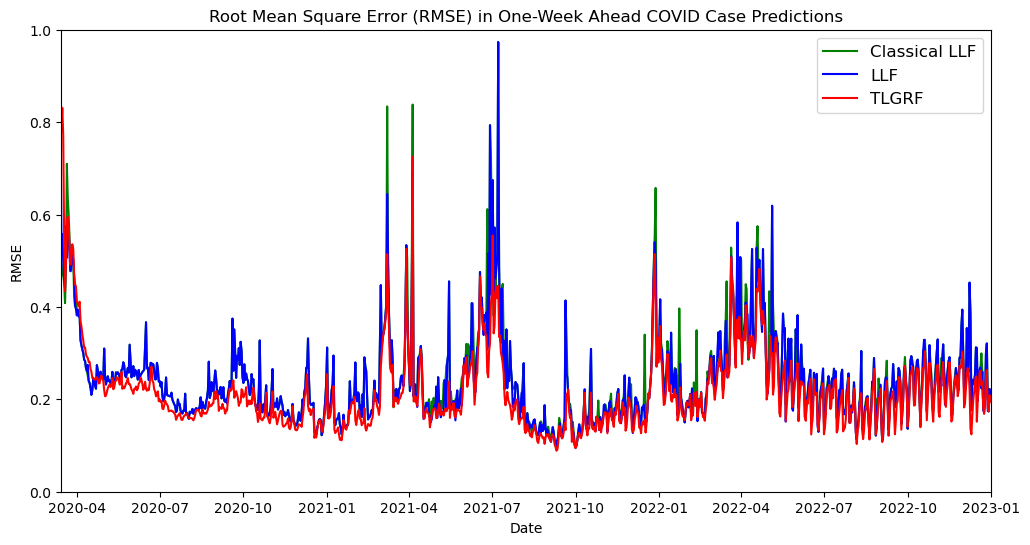

In [15]:
plt.figure(figsize=(12,6))

plt.plot(RMSE_classical_LLF_df, label="Classical LLF", color="green")
plt.plot(RMSE_LLF_df, label="LLF", color="blue")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")

plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("LLF_TLGRF_rmse.png")
plt.show()


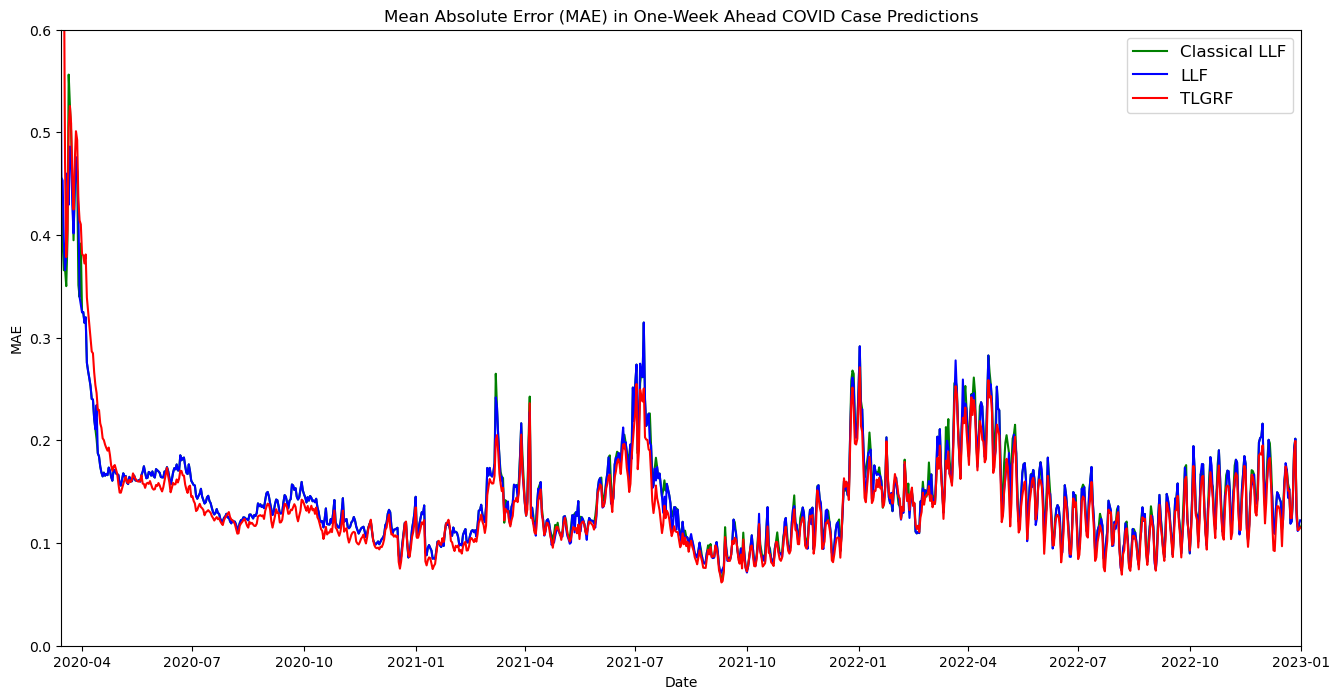

In [16]:
plt.figure(figsize=(16,8))

plt.plot(MAE_classical_LLF_df, label="Classical LLF", color="green")
plt.plot(MAE_LLF_df, label="LLF", color="blue")
plt.plot(MAE_TLGRF, label="TLGRF", color="red")

plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("LLF_TLGRF_mae.png")

plt.show()

In [17]:
RMSE_TLGRF.to_csv("RMSE_TLGRF.csv")
MAE_TLGRF.to_csv("MAE_TLGRF.csv")
RMSE_LLF_df.to_csv("RMSE_LLF_df.csv")
MAE_LLF_df.to_csv("MAE_LLF_df.csv")
RMSE_classical_LLF_df.to_csv("RMSE_classical_LLF_df.csv")
MAE_classical_LLF_df.to_csv("MAE_classical_LLF_df.csv")


### Compare `r` estimates

In [18]:
r_TLGRF_df = benchmark_TLGRF_dataset[["fips","days_from_start","date", "state","county","r_TLGRF"]]
r_LLF_df = llf_results[["fips","days_from_start","date", "state","county","r_LLF"]]
r_comparison_df = pd.merge(r_TLGRF_df, r_LLF_df[["fips","days_from_start","r_LLF"]], on=["fips","days_from_start"], how="inner")
r_comparison_df = r_comparison_df[r_comparison_df["date"] <= "2022-12-31"]
r_comparison_df["difference"] = r_comparison_df["r_TLGRF"] - r_comparison_df["r_LLF"]

display(r_comparison_df)

,fips,days_from_start,date,state,county,r_TLGRF,r_LLF,difference
0,1001,87,2020-04-17,Alabama,Autauga,0.028066,2.090668e-02,0.007159
1,1001,88,2020-04-18,Alabama,Autauga,0.007752,-4.186207e-15,0.007752
2,1001,89,2020-04-19,Alabama,Autauga,0.021119,1.369884e-02,0.007420
3,1001,90,2020-04-20,Alabama,Autauga,0.022045,2.020271e-02,0.001842
4,1001,91,2020-04-21,Alabama,Autauga,0.010171,-9.015990e-15,0.010171
...,...,...,...,...,...,...,...,...
2640541,99999,1071,2022-12-27,New York,New York City,-0.006383,-8.240652e-03,0.001858
2640542,99999,1072,2022-12-28,New York,New York City,-0.007237,-5.832859e-03,-0.001404
2640543,99999,1073,2022-12-29,New York,New York City,-0.008885,-5.851841e-03,-0.003033
2640544,99999,1074,2022-12-30,New York,New York City,-0.007669,-8.988563e-03,0.001320


In [19]:
grouped = r_comparison_df.groupby('date')

# Compute daily differences
daily_diff = grouped["difference"].mean().reset_index(name='difference')

In [20]:
display(daily_diff)

,date,difference
0,2020-03-10,NaN
1,2020-03-11,NaN
2,2020-03-12,-0.020585
3,2020-03-13,0.000380
4,2020-03-14,-0.000365
...,...,...
1020,2022-12-27,0.000577
1021,2022-12-28,-0.000059
1022,2022-12-29,-0.000074
1023,2022-12-30,0.001114


<Figure size 1600x800 with 0 Axes>

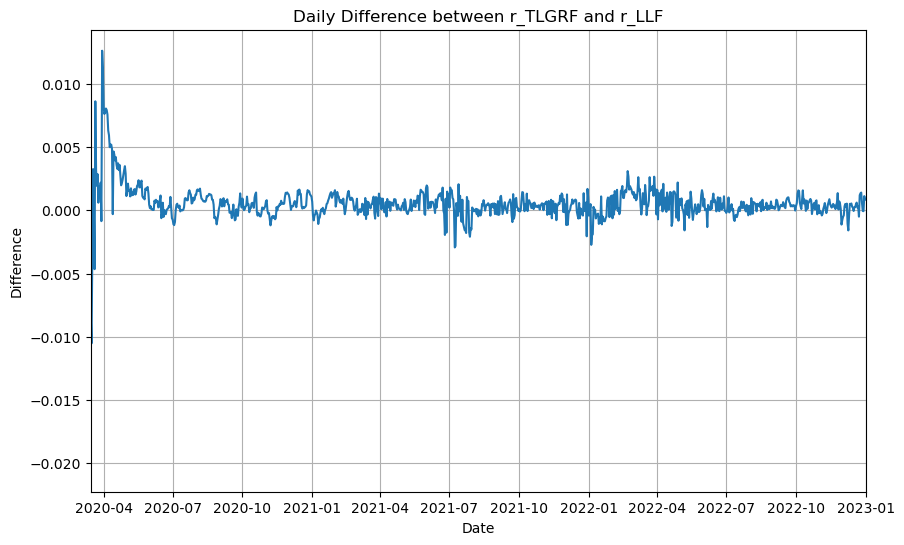

In [21]:
plt.figure(figsize=(16,8))

# Plot the differences
plt.figure(figsize=(10, 6))
plt.plot(daily_diff['date'], daily_diff['difference'])
plt.xlabel('Date')
plt.ylabel('Difference')
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))

plt.title('Daily Difference between r_TLGRF and r_LLF')
plt.grid(True)

plt.savefig("r_TLGRF vs r_LLF.png")

plt.show()
